In [1]:
import json
import pandas as pd
from matplotlib import pyplot as plt

## Load data

In [2]:
with open('simulation_config/config.json', 'r', encoding='utf-8') as fp:
    config = json.load(fp)

config.keys()

dict_keys(['step1', 'step2', 'step3'])

In [3]:
disease_name = config['step1']['disease_name']
disease_name

'COVID-19'

In [4]:
scenario_df = pd.DataFrame.from_dict(config['step2']['scenario_df'], orient='tight')
scenario_df

,x,date,y
0,0.000000,2024-07-01,1.980000
1,0.009346,2024-07-02,1.980000
2,0.018692,2024-07-03,1.980000
3,0.028037,2024-07-04,1.980004
4,0.037383,2024-07-05,1.980032
...,...,...,...
103,0.962617,2024-10-12,1.980000
104,0.971963,2024-10-13,1.980000
105,0.981308,2024-10-14,1.980000
106,0.990654,2024-10-15,1.980000


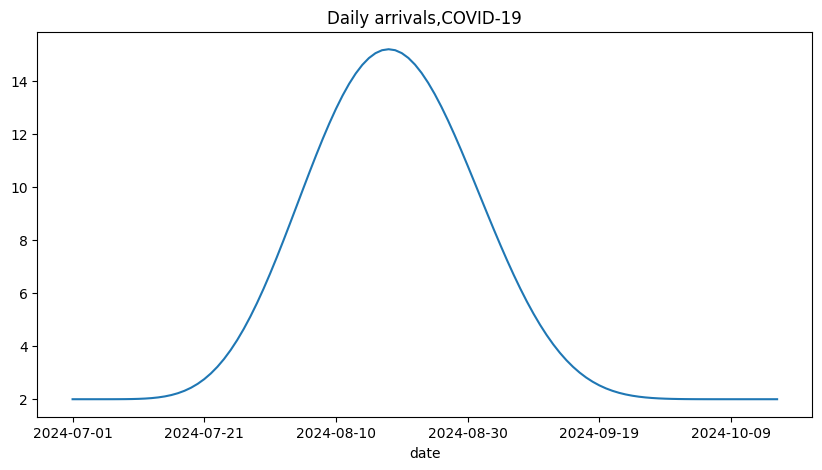

In [5]:
scenario_df.plot(x='date', y='y', kind='line',
                 title=f'Daily arrivals,{disease_name}',
                 figsize=(10, 5), legend=False)
plt.show()

In [6]:
age_df = pd.DataFrame.from_dict(config['step3']['age_groups'], orient='columns')
age_df

,lower,upper,query,ratio,dist_type,dist_params
0,0,16.0,Age >= 0 and Age < 16,0.040506,gamma,"{'a': 0.6331661087258936, 'loc': 0.60378074074..."
1,16,65.0,Age >= 16 and Age < 65,0.317722,chi2,"{'df': 1.2466507110020126, 'loc': 0.3656059259..."
2,65,NaN,Age >= 65,0.641772,gamma,"{'a': 1.069561598886756, 'loc': 0.195737660528..."


## Define simulation code

In [7]:
import random
from scipy import stats

def rand_los(age_df):
    age_ratios = age_df['ratio'].to_list()
    age_dist_types = age_df['dist_type'].to_list()
    age_dist_params = age_df['dist_params'].to_list()

    dists = []
    for dist_name, dist_params in zip(age_dist_types, age_dist_params):
        dist = getattr(stats, dist_name)(**dist_params)
        dists.append(dist)

    # Get the correct distribution based on the ratio
    idx = random.choices(range(len(age_ratios)), weights=age_ratios)[0]
    return dists[idx].rvs(), idx

[rand_los(age_df) for _ in range(10)]

[(0.6485670919765862, 2),
 (26.70036087086956, 1),
 (10.347047316939644, 2),
 (10.135888973398298, 2),
 (33.44378937383512, 1),
 (11.406851981889824, 1),
 (8.687349259515155, 2),
 (24.870795766199286, 2),
 (1.6607683221710718, 1),
 (3.4036099943401195, 1)]

In [8]:
import salabim as s

In [9]:
from datetime import datetime


class Patient(s.Component):
    """Represents a patient in the simulation."""

    def setup(self, los: float, age_idx: int):
        """Initialize the patient with length of stay and age index."""
        self.los = los
        self.age_idx = age_idx

    def process(self):
        """Process the patient by requesting resources and simulating length of stay."""
        self.request(self.env.beds)
        self.request(self.env.beds_by_age[self.age_idx])
        self.hold(self.env.days(self.los))
        self.release()  # Release all resources

class PatientGenerator(s.Component):
    """Generates patients based on the scenario DataFrame."""

    def setup(self, scenario_df, age_df, jitter=0.2):
        """Initialize generator parameters."""
        self.scenario_df = scenario_df
        self.age_df = age_df
        self.jitter = jitter

    def process(self):
        for _, row in self.scenario_df.iterrows():

            y = row['y']  # Number of patients to generate for this date
            # Apply jitter to the number of patients
            y *= s.random.uniform(1-self.jitter, 1+self.jitter)
            y = max(0, y)  # Ensure non-negative number of patients
            y = round(y)

            for _ in range(y):
                los, idx = rand_los(age_df)

                # Patient arrives at random time within the day
                delay = s.random.uniform(0, 1)
                Patient(env=self.env, delay=delay, los=los, age_idx=idx)

            self.hold(self.env.days(1))  # Wait for one day before generating the next batch


def sim(scenario_df, age_df, extra_days=25):
    """Simulate bed occupancy based on the patient arrivals scenario and age distribution."""
    env = s.Environment(time_unit='days', datetime0=scenario_df['date'].min(), random_seed='*')
    env.beds = s.Resource('Beds', env=env, capacity=s.inf)  # Use infinite-capacity resource as counter of occupied beds
    env.beds_by_age = [s.Resource(f'Beds for age group {i}', env=env, capacity=s.inf) for i in range(len(age_df))]
    env.patients = PatientGenerator(env=env, scenario_df=scenario_df, age_df=age_df)

    # Run until the last date in the scenario DataFrame
    till = datetime.fromisoformat(scenario_df['date'].max()) + pd.Timedelta(days=extra_days)
    env.run(till=env.datetime_to_t(till))

    beds_df = env.beds.claimed_quantity.as_dataframe()
    beds_df.columns = ['t', 'occupied_beds']
    beds_df['timestamp'] = beds_df.t.map(lambda x: env.t_to_datetime(x))
    beds_df = beds_df[['timestamp', 'occupied_beds']]
    beds_df = beds_df.set_index('timestamp', drop=True).sort_index()

    beds_df_by_age = {}

    for i in range(age_df.shape[0]):
        df = env.beds_by_age[i].claimed_quantity.as_dataframe()
        df.columns = ['t', 'occupied_beds']
        df['timestamp'] = df.t.map(lambda x: env.t_to_datetime(x))
        df = df[['timestamp', 'occupied_beds']]
        df = df.set_index('timestamp', drop=True).sort_index()
        beds_df_by_age[age_df['query'][i]] = df

    return beds_df, beds_df_by_age

## Single run of simulation

In [10]:
# Single run of the simulation
beds_df, beds_df_by_age = sim(scenario_df, age_df)

In [11]:
beds_df

,occupied_beds
timestamp,
2024-07-01 00:00:00.000000,0.0
2024-07-01 00:23:32.950535,1.0
2024-07-01 17:55:53.696966,2.0
2024-07-02 05:40:14.199793,3.0
2024-07-02 09:29:46.727602,4.0
...,...
2024-11-05 04:57:35.779997,25.0
2024-11-08 15:37:52.795444,24.0
2024-11-09 08:45:27.110279,23.0


In [12]:
def plot_daily_max_beds(beds_df, title: str):
    """Plot daily maximum bed occupancy."""
    beds_df.resample('1D').max().ffill().plot(figsize=(10, 5), legend=False)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Occupied Beds')
    plt.show()

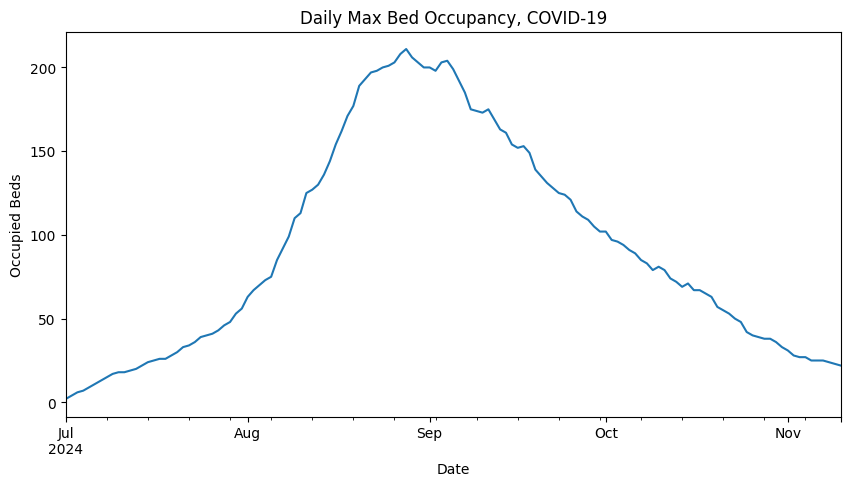

In [13]:
plot_daily_max_beds(beds_df, title=f'Daily Max Bed Occupancy, {disease_name}')

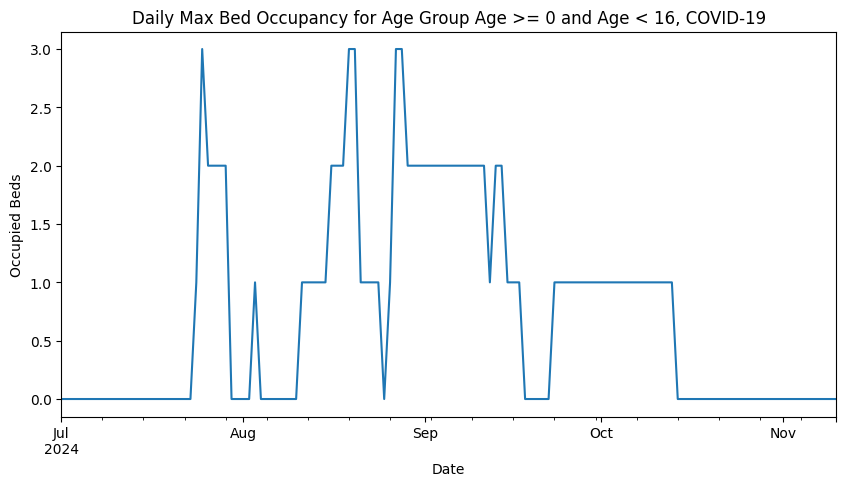

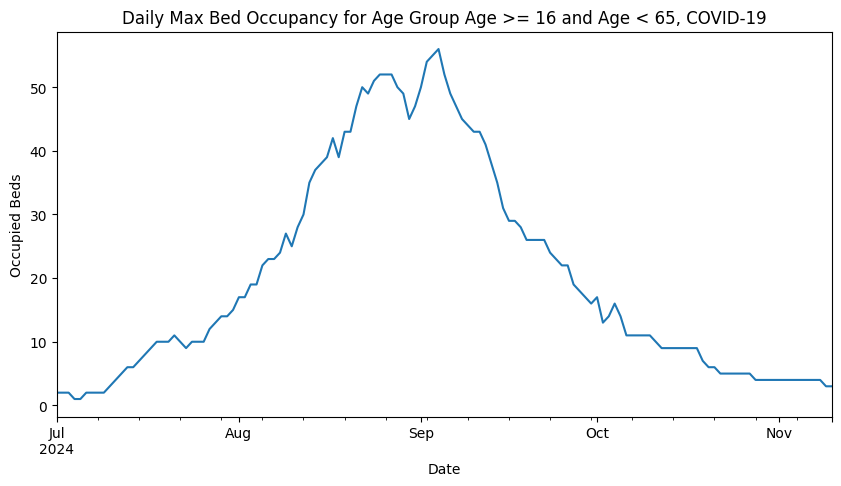

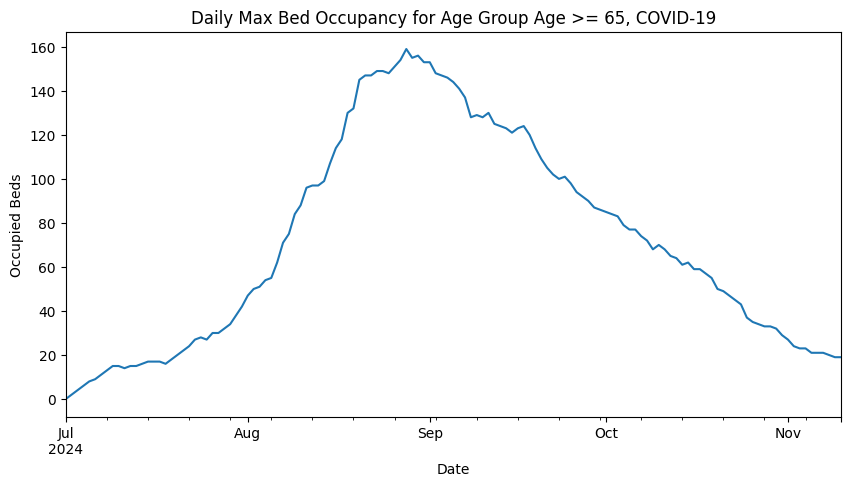

In [14]:
for group_name, beds_df_age in beds_df_by_age.items():
    plot_daily_max_beds(beds_df_age, title=f'Daily Max Bed Occupancy for Age Group {group_name}, {disease_name}')

In [15]:
beds_df_by_age.keys()

dict_keys(['Age >= 0 and Age < 16', 'Age >= 16 and Age < 65', 'Age >= 65'])

In [16]:
def resample(dfs, freq='1D'):
    return [df.resample(freq).max().ffill() for df in dfs]

def join_dfs(dfs, col_names):
    """Join multiple DataFrames on their index."""
    joined = pd.concat(dfs, axis=1)
    joined.columns = col_names
    return joined

In [17]:
beds_df_by_age_resampled = join_dfs(resample(beds_df_by_age.values()), beds_df_by_age.keys())
beds_df_by_age_resampled

,Age >= 0 and Age < 16,Age >= 16 and Age < 65,Age >= 65
timestamp,,,
2024-07-01,0.0,2.0,0.0
2024-07-02,0.0,2.0,2.0
2024-07-03,0.0,2.0,4.0
2024-07-04,0.0,1.0,6.0
2024-07-05,0.0,1.0,8.0
...,...,...,...
2024-11-06,0.0,4.0,21.0
2024-11-07,0.0,4.0,21.0
2024-11-08,0.0,4.0,20.0


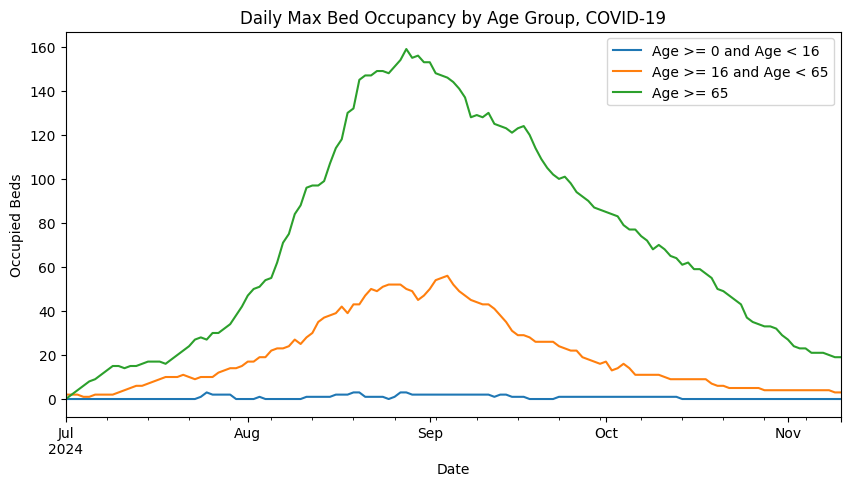

In [18]:
beds_df_by_age_resampled.plot(figsize=(10, 5), legend=True)
plt.title(f'Daily Max Bed Occupancy by Age Group, {disease_name}')
plt.xlabel('Date')
plt.ylabel('Occupied Beds')
plt.show()

## Multiple simulation runs

In [19]:
def sim_multiple(scenario_df, age_df, runs=30):
    """Run multiple simulations and return the results."""
    all_beds_df = []
    all_beds_df_by_age = []

    for _ in range(runs):
        beds_df, beds_df_by_age = sim(scenario_df, age_df)
        all_beds_df.append(beds_df)
        all_beds_df_by_age.append(beds_df_by_age)

    return all_beds_df, all_beds_df_by_age

sim30_results, sim30_results_by_age = sim_multiple(scenario_df, age_df, runs=30)

In [20]:
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

In [21]:
age_groups = list(sim30_results_by_age[0].keys())
age_groups

['Age >= 0 and Age < 16', 'Age >= 16 and Age < 65', 'Age >= 65']

## Plotly graphs

In [22]:
from plotly import graph_objects as go

def plot_quantiles_plotly(dfs, title: str):
    """Plot quantiles of multiple DataFrames."""
    quantiles = join_dfs(dfs, list(range(len(dfs))))\
        .quantile(q=QUANTILES, axis=1).T

    fig = go.Figure()

    # fill between lower and upper deciles
    fig.add_trace(go.Scatter(
        x=quantiles.index,
        y=quantiles[0.1],
        name='lower decile',
        line={'width': 0},
        legend=None
    ))
    fig.add_trace(go.Scatter(
        x=quantiles.index,
        y=quantiles[0.9],
        name='upper decile',
        fillcolor='rgba(127, 127, 255, 0.3)',  # Fill color with transparency
        fill='tonexty',
        line={'width': 0},
        legend=None
    ))

    # # fill between lower and upper quartiles
    fig.add_trace(go.Scatter(
        x=quantiles.index,
        y=quantiles[0.25],
        name='lower quartile',
        line={'width': 0},
        legend=None
    ))
    fig.add_trace(go.Scatter(
        x=quantiles.index,
        y=quantiles[0.75],
        name='upper quartile',
        fillcolor='rgba(0, 0, 255, 0.5)',  # Fill color with transparency
        fill='tonexty',
        line={'width': 0},
        legend=None
    ))

    # median line
    fig.add_trace(go.Scatter(
        x=quantiles.index,
        y=quantiles[0.5],
        mode='lines',
        name='median',
        line=dict(color='black', width=2),
        legend=None
    ))

    fig.update_layout(
        title=title,
        title_font_weight='bold',
        title_font_size=20,
        xaxis_title='Date',
        yaxis_title='Occupied Beds',
        legend_title='Quantiles',
        height=400,
        width=1000,
        legend_y=0.5,
        hovermode='x unified',
    )
    return fig, quantiles

fig, quantiles = plot_quantiles_plotly(resample(sim30_results), title=f'Daily Max Bed Occupancy, {disease_name}')
fig.show()
quantiles

,0.10,0.25,0.50,0.75,0.90
timestamp,,,,,
2024-07-01,2.0,2.00,2.0,2.00,2.0
2024-07-02,3.0,4.00,4.0,4.00,4.0
2024-07-03,5.0,5.00,6.0,6.00,6.0
2024-07-04,6.0,7.00,7.0,8.00,8.0
2024-07-05,7.0,8.00,9.0,10.00,10.0
...,...,...,...,...,...
2024-11-06,21.0,23.00,24.0,26.00,30.2
2024-11-07,19.9,21.25,23.0,25.75,30.1
2024-11-08,18.0,21.00,22.0,24.75,29.1


In [23]:
for age_group in age_groups:
    _range = range(len(sim30_results_by_age))
    tmp = resample([sim30_results_by_age[n][age_group] for n in _range])

    fig, _ = plot_quantiles_plotly(tmp, title=f'Daily Max Bed Occupancy for Age Group {age_group}, {disease_name}')
    fig.show()

In [24]:
def plot_quantiles_by_age(dfs, group_names: list[str], title: str = ''):
    if len(group_names) == 0:
        raise ValueError("Group names list is empty.")
    _range = range(len(dfs))
    # For each simulation replication, initialize values with the first age group
    values = [
        resample([dfs[n][group_names[0]] for n in _range])[n]
        for n in _range
    ]
    # Add subsequent age groups to the values
    for group_name in group_names[1:]:
        values = [
            values[n] + resample([dfs[n][group_name] for n in _range])[n]
            for n in _range
        ]
    fig, _ = plot_quantiles_plotly(values, title=title)
    return fig

# Plot quantiles for ages 16 and up (omit first age group)
fig = plot_quantiles_by_age(
    sim30_results_by_age,
    group_names=age_groups[1:],
    title=f'Daily Max Bed Occupancy for Age Group (16 and up), {disease_name}'
)
fig.show()